# Fitting a robust regression model using RANSAC

RANdom SAmple Consensus (RANSAC) algorithm follows the following steps:


1. Select a random number of examples to be inliers and fit the model.
2. Test all other data points against the fitted model and add those points that fall within a user-given tolerance to the inliers.
3. Refit the model using all inliers.
4. Estimate the error of the fitted model versus the inliers.
5. Terminate the algorithm if the performance meets a certain user-defined threshold or if a fixed number of iterations was reached; go back to step 1 otherwise.

In [1]:
import pandas as pd

columns = ['Overall Qual', 'Overall Cond', 'Gr Liv Area', 'Central Air', 'Total Bsmt SF', 'SalePrice']

df = pd.read_csv("http://jse.amstat.org/v19n3/decock/AmesHousing.txt", sep='\t', usecols= columns)
# not that we have limit the columns for the sake of simplicity

df.head()

df["Central Air"] = df["Central Air"].map({'N':0,"Y":1})

#print(df.head())

df = df.dropna(axis= 0) # remove row
df.isnull().sum()
#print(df.head())

# we willuse the Gr Liv Area instead of oval  because there seems to be linear relationship between them
X = df[["Gr Liv Area"]].values
Y = df["SalePrice"].values






In [2]:
from sklearn.linear_model import RANSACRegressor
from sklearn.linear_model import LinearRegression
rrc = RANSACRegressor(LinearRegression(), max_trials= 100, min_samples= 0.95, residual_threshold= None, random_state=12 )
# by setting residual_thresshold to NOne we limit to MAD
rrc.fit(X,Y)

,"estimator estimator: object, default=NoneBase estimator object which implements the following methods:* `fit(X, y)`: Fit model to given training data and target values.* `score(X, y)`: Returns the mean accuracy on the given test data, which is used for the stop criterion defined by `stop_score`. Additionally, the score is used to decide which of two equally large consensus sets is chosen as the better one.* `predict(X)`: Returns predicted values using the linear model, which is used to compute residual error using loss function.If `estimator` is None, then:class:`~sklearn.linear_model.LinearRegression` is used fortarget values of dtype float.Note that the current implementation only supports regressionestimators.",LinearRegression()
,"min_samples min_samples: int (>= 1) or float ([0, 1]), default=NoneMinimum number of samples chosen randomly from original data. Treatedas an absolute number of samples for `min_samples >= 1`, treated as arelative number `ceil(min_samples * X.shape[0])` for`min_samples < 1`. This is typically chosen as the minimal number ofsamples necessary to estimate the given `estimator`. By default a:class:`~sklearn.linear_model.LinearRegression` estimator is assumed and`min_samples` is chosen as ``X.shape[1] + 1``. This parameter is highlydependent upon the model, so if a `estimator` other than:class:`~sklearn.linear_model.LinearRegression` is used, the user mustprovide a value.",0.95
,"residual_threshold residual_threshold: float, default=NoneMaximum residual for a data sample to be classified as an inlier.By default the threshold is chosen as the MAD (median absolutedeviation) of the target values `y`. Points whose residuals arestrictly equal to the threshold are considered as inliers.",None
,"is_data_valid is_data_valid: callable, default=NoneThis function is called with the randomly selected data before themodel is fitted to it: `is_data_valid(X, y)`. If its return value isFalse the current randomly chosen sub-sample is skipped.",None
,"is_model_valid is_model_valid: callable, default=NoneThis function is called with the estimated model and the randomlyselected data: `is_model_valid(model, X, y)`. If its return value isFalse the current randomly chosen sub-sample is skipped.Rejecting samples with this function is computationally costlier thanwith `is_data_valid`. `is_model_valid` should therefore only be used ifthe estimated model is needed for making the rejection decision.",None
,"max_trials max_trials: int, default=100Maximum number of iterations for random sample selection.",100
,"max_skips max_skips: int, default=np.infMaximum number of iterations that can be skipped due to finding zeroinliers or invalid data defined by ``is_data_valid`` or invalid modelsdefined by ``is_model_valid``... versionadded:: 0.19",inf
,"stop_n_inliers stop_n_inliers: int, default=np.infStop iteration if at least this number of inliers are found.",inf
,"stop_score stop_score: float, default=np.infStop iteration if score is greater equal than this threshold.",inf
,"stop_probability stop_probability: float in range [0, 1], default=0.99RANSAC iteration stops if at least one outlier-free set of the trainingdata is sampled in RANSAC. This requires to generate at least Nsamples (iterations):: N >= log(1 - probability) / log(1 - e**m)where the probability (confidence) is typically set to high value suchas 0.99 (the default) and e is the current fraction of inliers w.r.t.the total number of samples.",0.99
,"loss loss: str, callable, default='absolute_error'String inputs, 'absolute_error' and 'squared_error' are supported whichfind the absolute error and squared error per sample respectively.If ``loss`` is a callable, then it should be a function that takestwo arrays as inputs, the true and predicted value and returns a 1-Darray with the i-th value of the array corresponding to the losson ``X[i]``.If the loss on a sample is greater than the ``residual_threshold``,then this sample is classified as an outlier... versionadded:: 0.18"

[3 4 5 6 7 8 9]
[ True  True  True ...  True  True False]


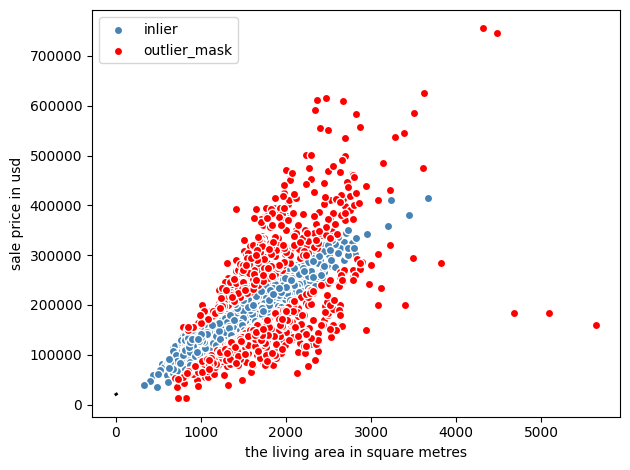

In [3]:
inlier_mask = rrc.inlier_mask_
import numpy as np
outlier_mask = np.logical_not(inlier_mask)
line_x = np.arange(3, 10, 1)
print(line_x)
line_x_ransac = rrc.predict(line_x[:, np.newaxis])
print(inlier_mask)
import matplotlib.pyplot as plt

plt.scatter(X[inlier_mask], Y[inlier_mask], c = "steelblue", edgecolors= "white", marker = 'o', label = "inlier")

plt.scatter(X[outlier_mask], Y[outlier_mask], c = "red", edgecolors= "white", marker = 'o', label = "outlier_mask")

plt.plot(line_x, line_x_ransac, color = "black", lw = 2)

plt.xlabel("the living area in square metres")
plt.ylabel("sale price in usd")
plt.legend(loc = "upper left")
plt.tight_layout()